# Day 062 — Non-Linear Dimensionality Reduction: t-SNE & UMAP

> **Goal**: Linear methods like PCA fail to capture **non-linear manifolds** in high-dimensional data. Today, we will master two powerful non-linear dimensionality reduction techniques — **t-SNE** and **UMAP** — to effectively project and visualize complex high-dimensional data structures in 2D and 3D.


In [5]:
# ============================================================
# Setup & Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('All imports ready!')


All imports ready!


---
## 1. The Manifold Hypothesis & Why PCA Fails

### 🧠 Core Idea: The Manifold Hypothesis

Real-world high-dimensional data (such as images, text embeddings, and gene expression profiles) typically lies on a **low-dimensional manifold** embedded within the higher-dimensional ambient space.

**Example**: Imagine a sheet of paper crumpled into a 3D ball. The paper itself is a **2D manifold** residing inside a **3D space**. Linear PCA attempts to fit a flat plane through the 3D ball, failing to "uncrumple" the underlying sheet.

### 📉 Why PCA Fails on Non-Linear Data

| Property | PCA | Manifold Learning Methods |
|----------|-----|--------------------------|
| Transformation | **Linear** (rotation + orthogonal projection) | **Non-linear** (neighborhood-preserving mapping) |
| Preserves | Global variance / covariance | **Local neighborhood relationships** |
| Works well when | Data points follow an ellipsoidal distribution | Data points lie along curved, non-linear manifolds |
| Fails when | Swiss rolls, S-curves, complex structures | — |

### 🎯 Manifold Learning Methods

| Method | Introduced | Core Mechanism |
|--------|------------|----------------|
| **Isomap** | 2000 | Geodesic distance matrices + Multidimensional Scaling (MDS) |
| **LLE** | 2000 | Local linear reconstruction weights preservation |
| **t-SNE** | 2008 | Probability distributions matching via KL divergence |
| **UMAP** | 2018 | Fuzzy simplicial sets & cross-entropy optimization |


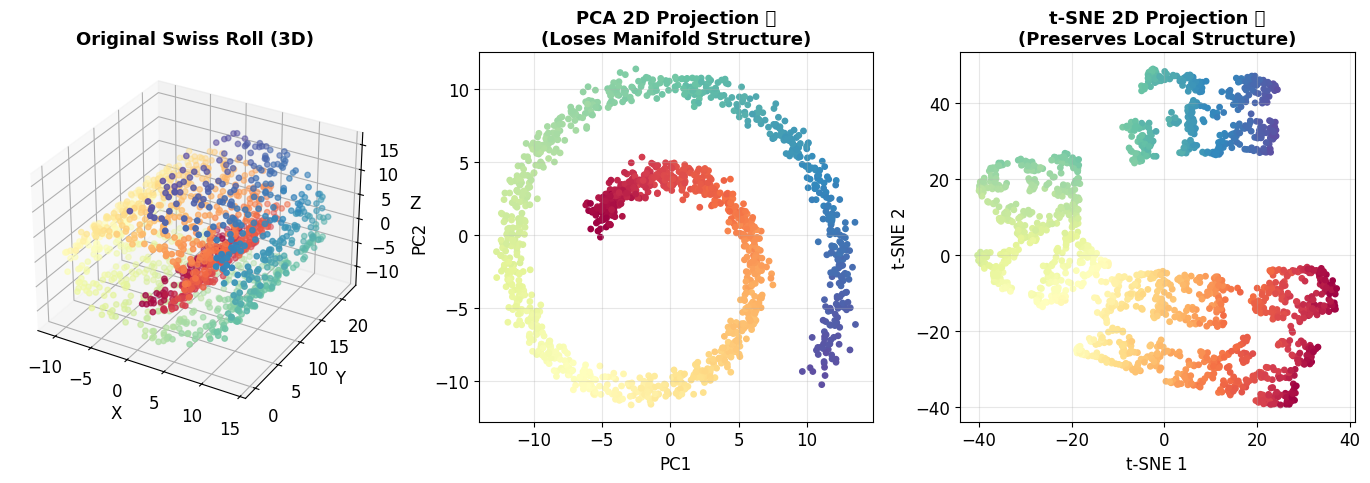

In [6]:
# ── Demo: PCA fails on Swiss Roll ──
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA

X_swiss, color = make_swiss_roll(n_samples=1500, noise=0.5, random_state=42)

fig = plt.figure(figsize=(14, 5))

# 3D Swiss Roll
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=color, cmap='Spectral', s=15)
ax1.set_title('Original Swiss Roll (3D)', fontsize=13, fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

# PCA projection — FAILS (flattens the roll)
X_pca = PCA(n_components=2).fit_transform(X_swiss)
ax2 = fig.add_subplot(132)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap='Spectral', s=15)
ax2.set_title('PCA 2D Projection ❌\n(Loses Manifold Structure)', fontsize=13, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

# t-SNE — preserves local structure
from sklearn.manifold import TSNE
X_tsne_swiss = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_swiss)
ax3 = fig.add_subplot(133)
ax3.scatter(X_tsne_swiss[:, 0], X_tsne_swiss[:, 1], c=color, cmap='Spectral', s=15)
ax3.set_title('t-SNE 2D Projection ✅\n(Preserves Local Structure)', fontsize=13, fontweight='bold')
ax3.set_xlabel('t-SNE 1'); ax3.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()


---
## 2. t-SNE: Theory & Mathematical Foundation

### 📖 Full Name: t-Distributed Stochastic Neighbor Embedding

**Developed by**: Laurens van der Maaten & Geoffrey Hinton (2008)

### 🔬 Algorithm — Step by Step

#### Step 1: Pairwise Similarities in High-Dimensional Space

For each pair of data points $(x_i, x_j)$, compute the **conditional probability** $p_{j|i}$ that point $x_i$ selects $x_j$ as its neighbor under a **Gaussian** distribution centered at $x_i$:

$$p_{j|i} = \frac{\exp\left(-\|x_i - x_j\|^2 \,/\, 2\sigma_i^2\right)}{\sum_{k \neq i} \exp\left(-\|x_i - x_k\|^2 \,/\, 2\sigma_i^2\right)}$$

To make the pairwise probability symmetric, joint probabilities $p_{ij}$ are calculated:

$$p_{ij} = \frac{p_{j|i} + p_{i|j}}{2n}$$

where $n$ represents the total number of samples.

#### Step 2: Pairwise Similarities in Low-Dimensional Space

In the low-dimensional target space ($y_i, y_j$), a heavy-tailed **Student-t distribution** (with 1 degree of freedom, equivalent to a Cauchy distribution) is used instead of a Gaussian distribution:

$$q_{ij} = \frac{\left(1 + \|y_i - y_j\|^2\right)^{-1}}{\sum_{k \neq l} \left(1 + \|y_k - y_l\|^2\right)^{-1}}$$

> **Why Student-t?** The heavy tails of the Student-t distribution allow moderate distances in high-dimensional space to map to larger distances in the low-dimensional embedding. This directly addresses and resolves the **crowding problem**, preventing points from collapsing into a dense central region.

#### Step 3: Minimizing KL Divergence

The embedding coordinates $y_i$ are optimized by minimizing the **Kullback-Leibler (KL) divergence** between distributions $P$ and $Q$:

$$C = KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

Optimization is performed using **gradient descent**, where the gradient with respect to $y_i$ is:

$$\frac{\partial C}{\partial y_i} = 4 \sum_j (p_{ij} - q_{ij})(y_i - y_j)\left(1 + \|y_i - y_j\|^2\right)^{-1}$$

### 🎛️ Key Hyperparameter: Perplexity

Perplexity effectively determines the smooth measure of the number of nearest neighbors:

$$\text{Perplexity} = 2^{H(P_i)}$$

where $H(P_i) = -\sum_j p_{j|i} \log_2 p_{j|i}$ is the Shannon entropy of $P_i$.

| Perplexity Value | Effect on Embedding |
|------------------|---------------------|
| **Low (5-10)** | Focuses strictly on local structure; clusters may fragment |
| **Medium (30-50)** | Well-balanced representation of local and moderate global structure |
| **High (100+)** | Captures global macro-structure; clusters merge, output resembles PCA |

> **Practical Rule**: Typical perplexity values range between 5 and 50. Larger datasets generally benefit from higher perplexity values.


Digits Dataset: 800 samples, 64 features
Classes: [0 1 2 3 4 5 6 7 8 9] (10 digits)


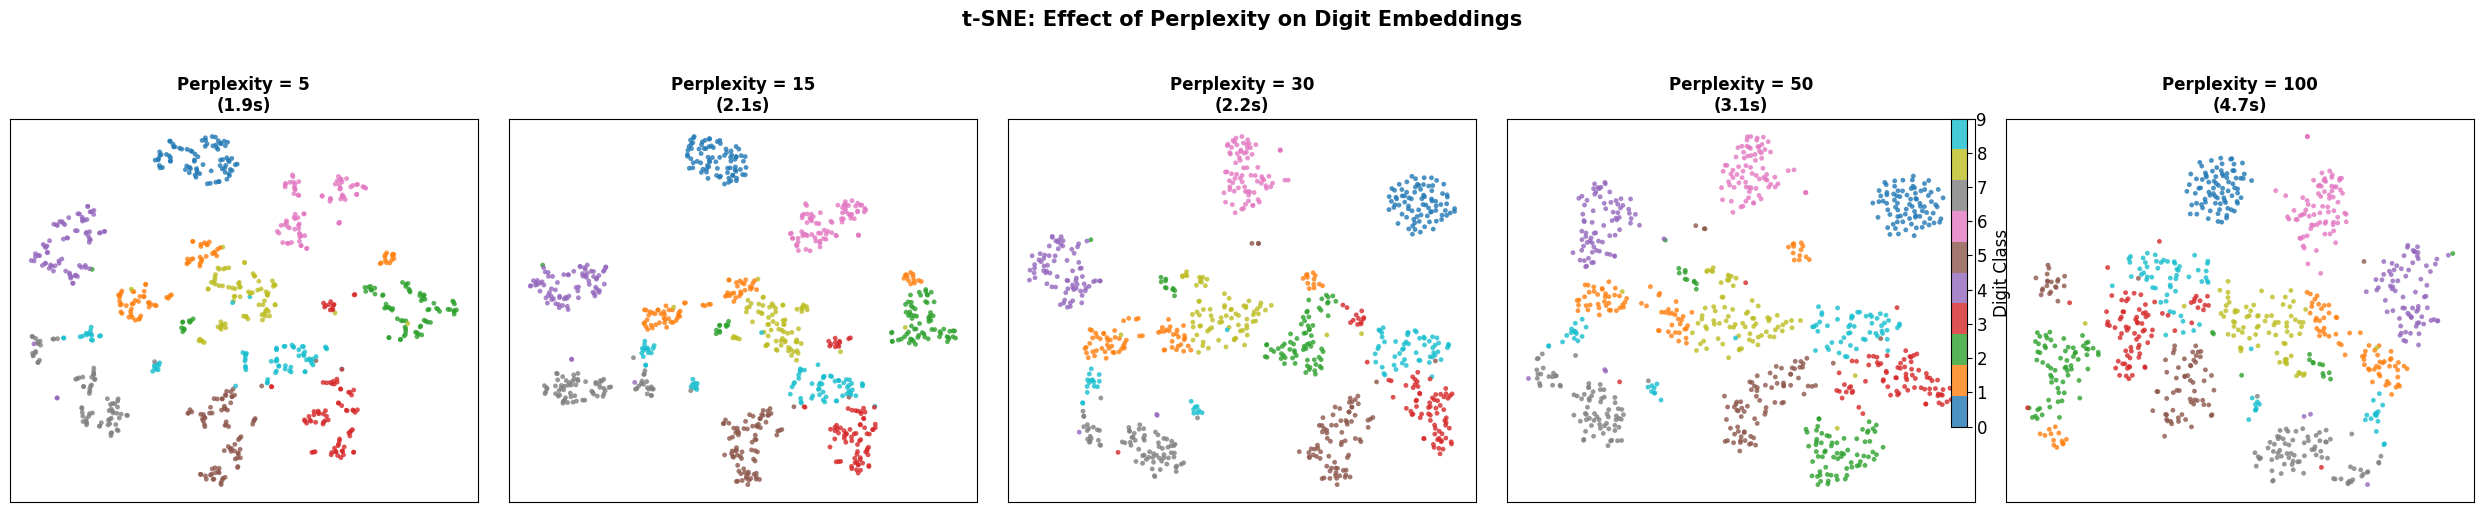

In [8]:
# ── t-SNE: Perplexity Parameter Sweep ──
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Load digits dataset (64-dimensional)
digits = load_digits()
X_digits = digits.data[:800]   # Sample size for execution speed
y_digits = digits.target[:800]
X_scaled = StandardScaler().fit_transform(X_digits)

print(f'Digits Dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features')
print(f'Classes: {np.unique(y_digits)} ({len(np.unique(y_digits))} digits)')

# Run t-SNE with different perplexities
perplexities = [5, 15, 30, 50, 100]
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, perp in zip(axes, perplexities):
    t0 = time()
    X_emb = TSNE(n_components=2, perplexity=perp, random_state=42, learning_rate='auto', init='pca').fit_transform(X_scaled)
    elapsed = time() - t0
    
    scatter = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_digits, cmap='tab10',
                        s=12, alpha=0.8, edgecolors='none')
    ax.set_title(f'Perplexity = {perp}\n({elapsed:.1f}s)', fontsize=12, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('t-SNE: Effect of Perplexity on Digit Embeddings', fontsize=15, fontweight='bold', y=1.02)
plt.colorbar(scatter, ax=axes.ravel().tolist(), label='Digit Class', shrink=0.8)
plt.tight_layout()
plt.show()


---
## 3. t-SNE: Important Caveats & Pitfalls

### ⚠️ Essential Pitfalls to Avoid in t-SNE Interpretation

| Pitfall | Explanation |
|---------|-------------|
| **Cluster sizes are meaningless** | t-SNE adapts to local density variations; visual cluster area does not reflect feature space variance. |
| **Inter-cluster distances are not scale-preserved** | Distance between separate clusters cannot be reliably interpreted as metric distance. |
| **Stochastic nature** | Non-deterministic optimization; results vary across runs unless `random_state` is fixed. |
| **No parametric mapping** | Cannot transform new unseen data directly without re-running optimization. |
| **Computational complexity** | Quadratic $O(n^2)$ complexity; use Barnes-Hut or FFT-accelerated variants (FIt-SNE) for large data. |
| **Not for supervised training** | Embedding coordinates are meant strictly for visual inspection, not downstream modeling features. |

### ✅ Best Practices
1. Always **standardize** features prior to running t-SNE.
2. Apply **PCA preprocessing** first to reduce dimensions to ~50 components before t-SNE.
3. Evaluate embeddings across **multiple perplexity settings**.
4. Utilize `learning_rate='auto'` and `init='pca'` initialization.


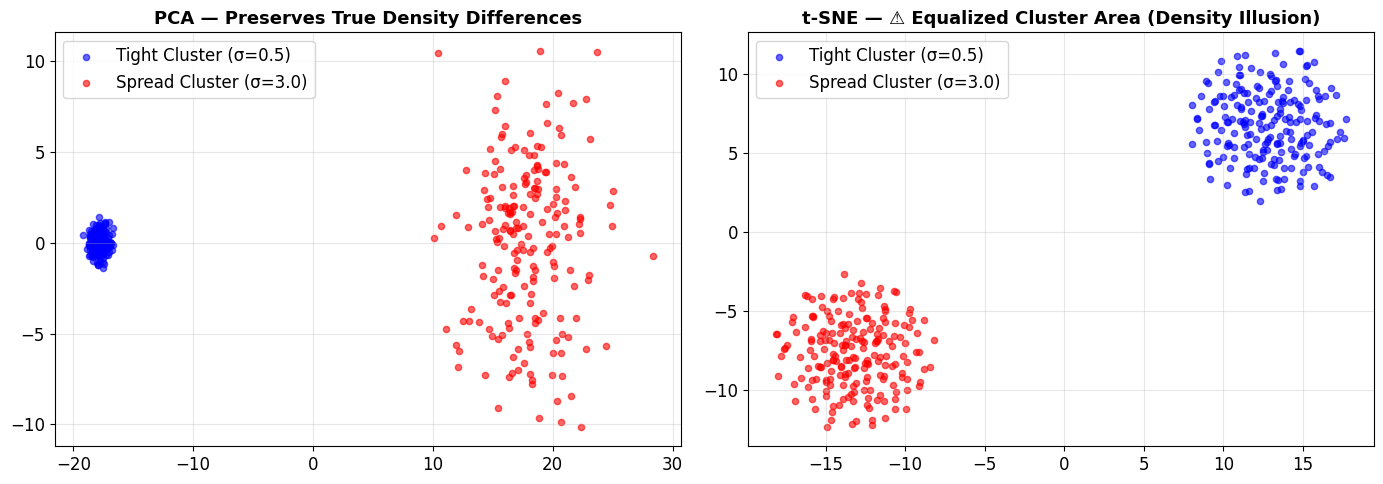

Key Insight: t-SNE normalizes local density — visual cluster size does NOT reflect feature variance!


In [9]:
# ── Caveat Demo: Cluster Size Illusion ──
# Two clusters of very different densities
np.random.seed(42)
cluster_tight = np.random.normal(0, 0.5, (200, 50))   # σ=0.5 (tight)
cluster_spread = np.random.normal(5, 3.0, (200, 50))   # σ=3.0 (spread)
X_demo = np.vstack([cluster_tight, cluster_spread])
y_demo = np.array([0]*200 + [1]*200)

X_tsne_demo = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_demo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# True structure (PCA)
from sklearn.decomposition import PCA
X_pca_demo = PCA(n_components=2).fit_transform(X_demo)
ax1.scatter(X_pca_demo[:200, 0], X_pca_demo[:200, 1], c='blue', s=20, alpha=0.6, label='Tight Cluster (σ=0.5)')
ax1.scatter(X_pca_demo[200:, 0], X_pca_demo[200:, 1], c='red', s=20, alpha=0.6, label='Spread Cluster (σ=3.0)')
ax1.set_title('PCA — Preserves True Density Differences', fontsize=13, fontweight='bold')
ax1.legend()

# t-SNE — Clusters appear equal in size
ax2.scatter(X_tsne_demo[:200, 0], X_tsne_demo[:200, 1], c='blue', s=20, alpha=0.6, label='Tight Cluster (σ=0.5)')
ax2.scatter(X_tsne_demo[200:, 0], X_tsne_demo[200:, 1], c='red', s=20, alpha=0.6, label='Spread Cluster (σ=3.0)')
ax2.set_title('t-SNE — ⚠️ Equalized Cluster Area (Density Illusion)', fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()
print('Key Insight: t-SNE normalizes local density — visual cluster size does NOT reflect feature variance!')


---
## 4. UMAP: Theory & Mathematical Foundation

### 📖 Full Name: Uniform Manifold Approximation and Projection

**Developed by**: Leland McInnes, John Healy & James Melville (2018)

### 🔬 Algorithm — Mathematical Concepts

UMAP is rooted in Riemannian geometry and algebraic topology:

#### Step 1: Construct a Weighted k-Nearest Neighbor Graph

For each data point $x_i$, compute local edge weights to its $k$ nearest neighbors:

$$w(x_i, x_j) = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)$$

where:
- $d(x_i, x_j)$ represents distance between points.
- $\rho_i$ is the distance from $x_i$ to its **nearest neighbor** (ensures local connectivity).
- $\sigma_i$ is the local scaling parameter calibrated to match the target metric space.

#### Step 2: Form Fuzzy Simplicial Set

Directed edge weights are symmetrized via a probabilistic fuzzy union:

$$w_{sym}(x_i, x_j) = w(x_i, x_j) + w(x_j, x_i) - w(x_i, x_j) \cdot w(x_j, x_i)$$

This constructs a continuous **fuzzy topological representation** of the high-dimensional manifold.

#### Step 3: Optimize Low-Dimensional Embedding

In the low-dimensional embedding space, edge probabilities $v(y_i, y_j)$ are defined as:

$$v(y_i, y_j) = \left(1 + a \cdot \|y_i - y_j\|^{2b}\right)^{-1}$$

where parameters $a$ and $b$ are fitted based on the `min_dist` user specification.

Optimization minimizes the **fuzzy set cross-entropy** between target and source graphs:

$$C = \sum_{i \neq j} \left[ w_{ij} \log\frac{w_{ij}}{v_{ij}} + (1-w_{ij}) \log\frac{1-w_{ij}}{1-v_{ij}} \right]$$

### 🎛️ Key Hyperparameters

| Parameter | Default | Function |
|-----------|---------|----------|
| `n_neighbors` | 15 | Controls local vs. global balance (larger values preserve macro-structure) |
| `min_dist` | 0.1 | Controls minimum packing distance between embedded points |
| `metric` | 'euclidean' | Distance metric choice (supports cosine, manhattan, minkowski) |
| `n_components` | 2 | Number of target output dimensions |


umap-learn not installed. Run: pip install umap-learn
Falling back to Isomap for manifold projection...


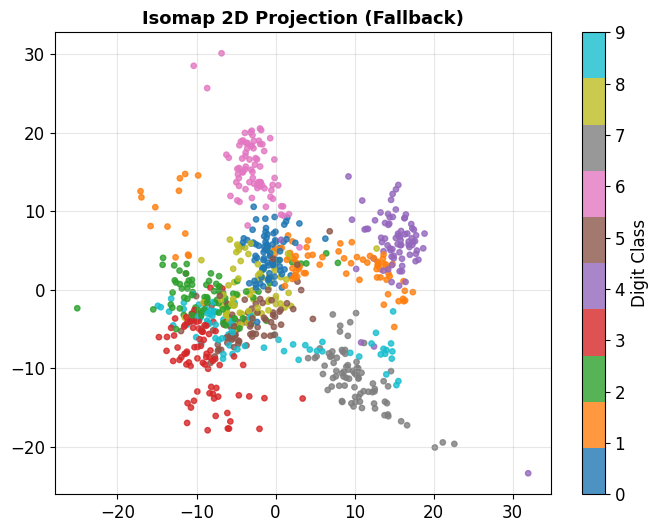

In [10]:
# ── UMAP: n_neighbors & min_dist Parameter Sweep ──
try:
    import umap
    
    n_neighbors_list = [5, 15, 50]
    min_dist_list = [0.0, 0.1, 0.5]
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    
    for i, nn in enumerate(n_neighbors_list):
        for j, md_val in enumerate(min_dist_list):
            t0 = time()
            reducer = umap.UMAP(n_neighbors=nn, min_dist=md_val, random_state=42)
            X_umap = reducer.fit_transform(X_scaled)
            elapsed = time() - t0
            
            ax = axes[i][j]
            ax.scatter(X_umap[:, 0], X_umap[:, 1], c=y_digits, cmap='tab10',
                       s=12, alpha=0.8, edgecolors='none')
            ax.set_title(f'n_neighbors={nn}, min_dist={md_val}\n({elapsed:.1f}s)',
                         fontsize=11, fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([])
    
    plt.suptitle('UMAP: Effect of n_neighbors & min_dist on Digit Embeddings',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

except ImportError:
    print('umap-learn not installed. Run: pip install umap-learn')
    print('Falling back to Isomap for manifold projection...')
    
    from sklearn.manifold import Isomap
    X_iso = Isomap(n_components=2, n_neighbors=15).fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y_digits, cmap='tab10', s=15, alpha=0.8)
    plt.title('Isomap 2D Projection (Fallback)', fontsize=13, fontweight='bold')
    plt.colorbar(label='Digit Class')
    plt.show()


---
## 5. Comprehensive Comparison: PCA vs t-SNE vs UMAP

### 📊 Feature Comparison Matrix

| Feature | PCA | t-SNE | UMAP |
|---------|-----|-------|------|
| **Transformation** | Linear | Non-linear | Non-linear |
| **Preserves** | Global variance | Local neighborhoods | Local & Global structure |
| **Speed** | Extremely Fast ($O(dn^2)$) | Slower ($O(n^2)$) | Fast ($O(n \log n)$) |
| **Scalability** | Millions of samples | Best for $< 10K$ samples | Easily scales to $100K+$ |
| **Determinism** | Deterministic | Stochastic | Stochastic |
| **Transform New Data** | Yes (`.transform()`) | No | Yes (`.transform()`) |
| **Downstream ML Features** | Excellent | Not recommended | Acceptable with caution |
| **Primary Metric** | `n_components` | `perplexity` | `n_neighbors`, `min_dist` |

### 🎯 Decision Framework

- **PCA**: Baseline exploration, linear feature extraction, computationally constrained pipelines.
- **t-SNE**: High-quality 2D/3D cluster visualizations for moderate-sized datasets ($<10K$).
- **UMAP**: Large-scale non-linear data visualization, preserving global inter-cluster topology, out-of-sample data projection.


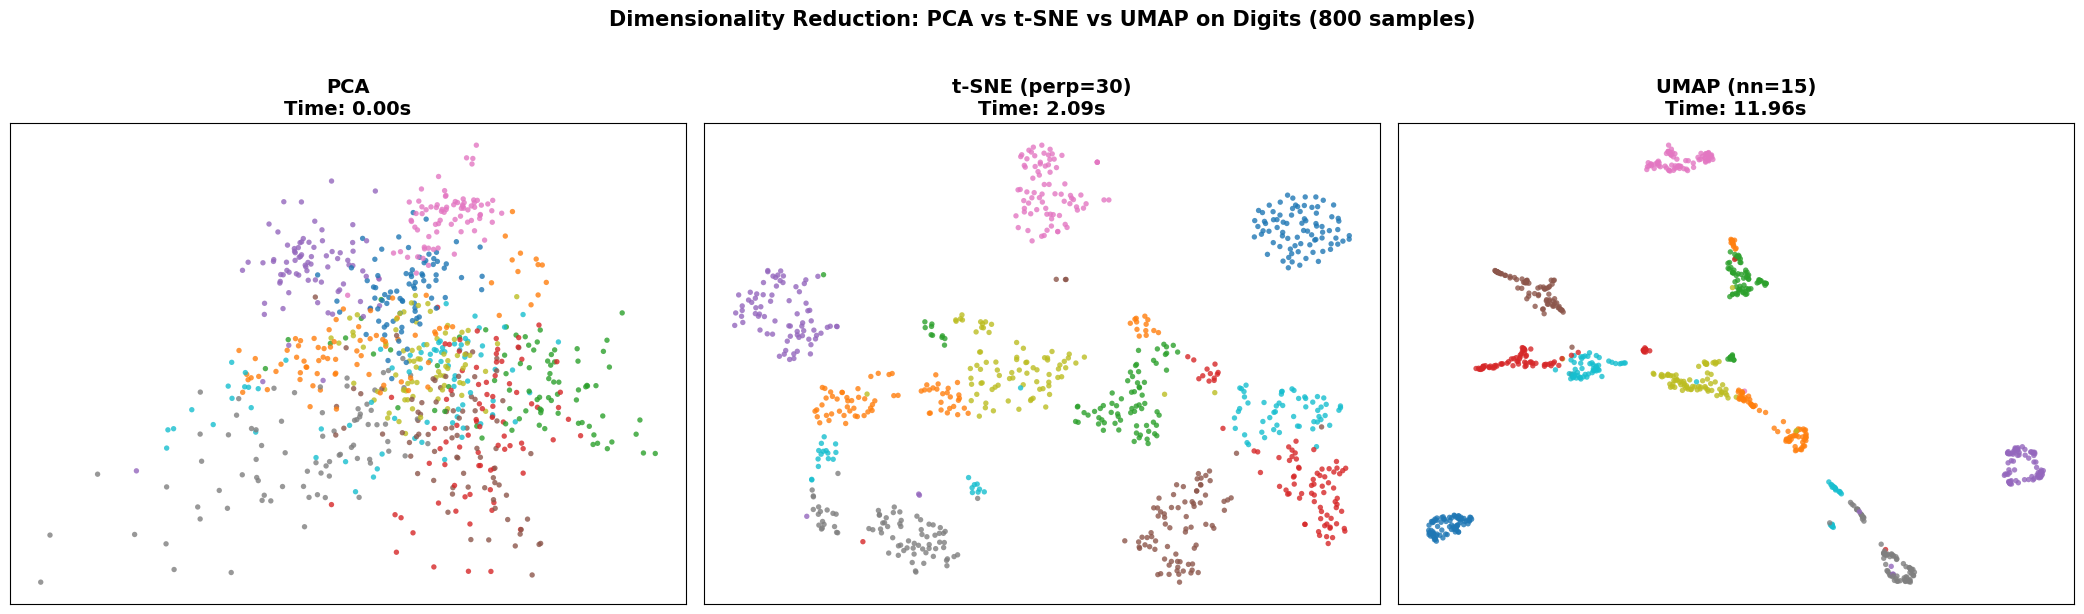

Timing Summary:
  PCA                 : 0.001s
  t-SNE (perp=30)     : 2.088s
  UMAP (nn=15)        : 11.964s


In [15]:
# ── Side-by-Side Visual + Timing Comparison ──
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

methods = {
    'PCA': lambda X: PCA(n_components=2).fit_transform(X),
    't-SNE (perp=30)': lambda X: TSNE(n_components=2, perplexity=30,
                                       random_state=42, init='pca',
                                       learning_rate='auto').fit_transform(X),
}

try:
    import umap
    methods['UMAP (nn=15)'] = lambda X: umap.UMAP(n_neighbors=15, min_dist=0.1,
                                                    random_state=42).fit_transform(X)
except ImportError:
    pass

fig, axes = plt.subplots(1, len(methods), figsize=(7 * len(methods), 6))
if len(methods) == 1:
    axes = [axes]

timings = {}
for ax, (name, func) in zip(axes, methods.items()):
    t0 = time()
    X_emb = func(X_scaled)
    elapsed = time() - t0
    timings[name] = elapsed
    
    scatter = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_digits, cmap='tab10',
                        s=15, alpha=0.8, edgecolors='none')
    ax.set_title(f'{name}\nTime: {elapsed:.2f}s', fontsize=14, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Dimensionality Reduction: PCA vs t-SNE vs UMAP on Digits (800 samples)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Timing Summary:')
for name, t in timings.items():
    print(f'  {name:20s}: {t:.3f}s')


---
## 6. 3D Manifold Projection

Projecting data into 3D space can resolve overlapping cluster boundaries that remain ambiguous in 2D projections.


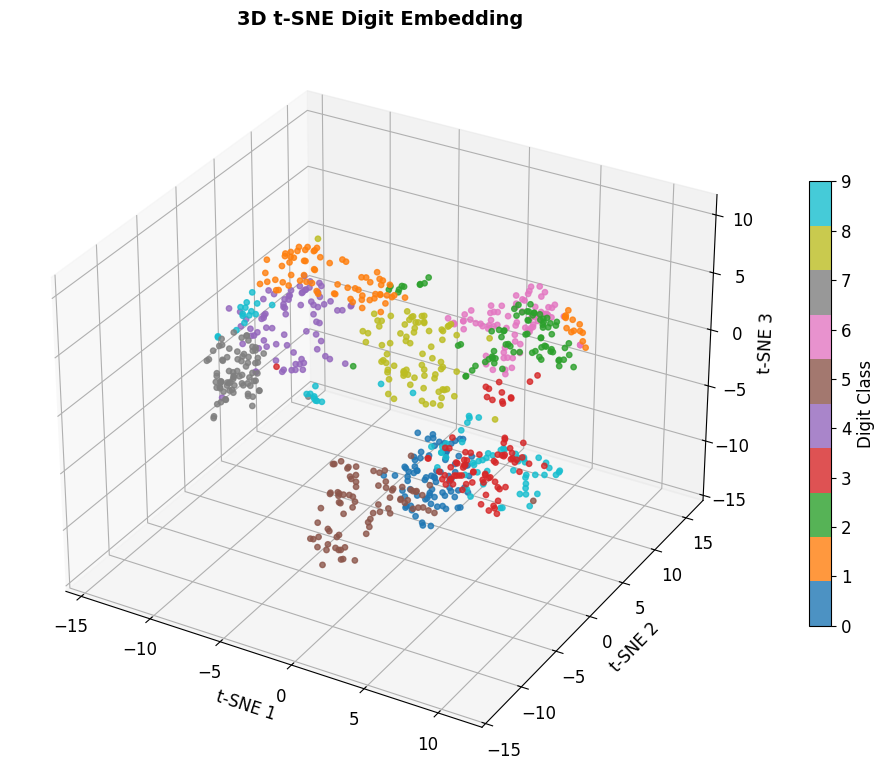

In [12]:
# ── 3D t-SNE Embedding ──
tsne_3d = TSNE(n_components=3, perplexity=30, random_state=42,
               init='pca', learning_rate='auto')
X_3d = tsne_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2],
               c=y_digits, cmap='tab10', s=15, alpha=0.8)
ax.set_title('3D t-SNE Digit Embedding', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.set_zlabel('t-SNE 3')
fig.colorbar(p, shrink=0.6, label='Digit Class')
plt.tight_layout()
plt.show()


---
## 7. Production Best Practices: Scaler → PCA → UMAP/t-SNE Pipeline

### 🏗️ Recommended Preprocessing Architecture

For datasets with $> 50$ original features:
1. **StandardScaler**: Standardize features to zero mean and unit variance.
2. **PCA (50 Components)**: Retains $>90\%$ variance while suppressing uncorrelated noise and reducing computation time.
3. **t-SNE / UMAP**: Map 50D PCA representations down to 2D/3D for visual assessment.


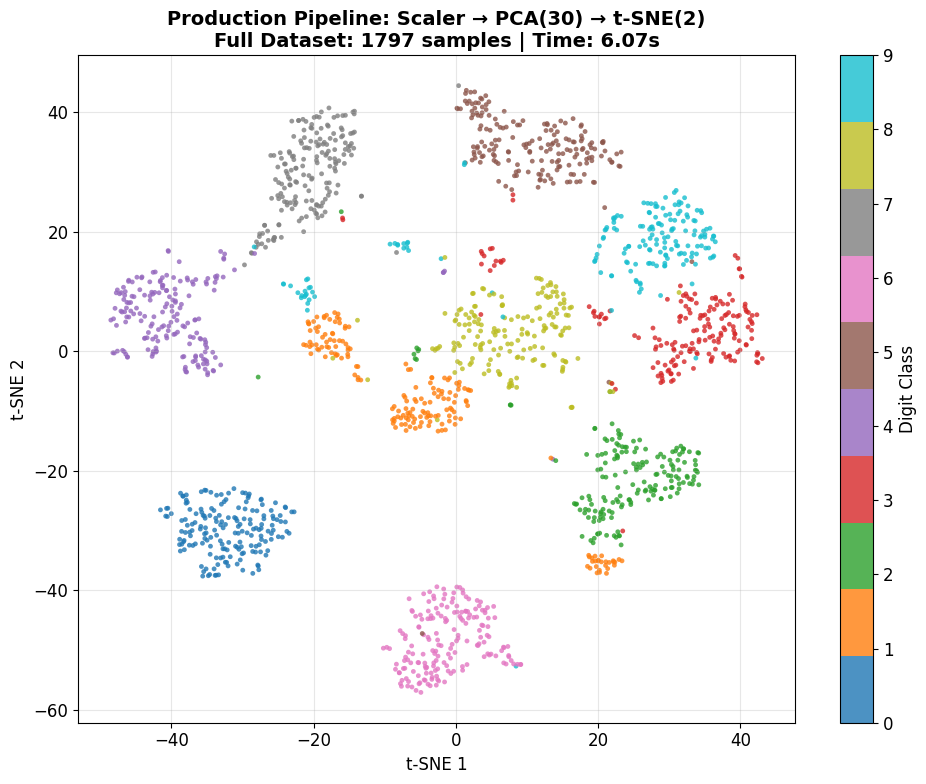

PCA Step: 30 components explain 89.3% variance
Total pipeline execution time: 6.07s


In [13]:
# ── Production Pipeline: StandardScaler → PCA(30) → t-SNE(2) ──
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_full = load_digits().data
y_full = load_digits().target

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=30, random_state=42)),
    ('tsne', TSNE(n_components=2, perplexity=30, random_state=42,
                  init='pca', learning_rate='auto'))
])

t0 = time()
X_final = pipe.fit_transform(X_full)
elapsed = time() - t0

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_final[:, 0], X_final[:, 1], c=y_full, cmap='tab10',
                      s=12, alpha=0.8, edgecolors='none')
plt.colorbar(scatter, label='Digit Class')
plt.title(f'Production Pipeline: Scaler → PCA(30) → t-SNE(2)\n'
          f'Full Dataset: {X_full.shape[0]} samples | Time: {elapsed:.2f}s',
          fontsize=14, fontweight='bold')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

pca_step = pipe.named_steps['pca']
print(f'PCA Step: {pca_step.n_components_} components explain '
      f'{pca_step.explained_variance_ratio_.sum()*100:.1f}% variance')
print(f'Total pipeline execution time: {elapsed:.2f}s')


---
## 📝 Key Takeaways

1. **Manifold Hypothesis**: High-dimensional data often concentrates along lower-dimensional non-linear manifolds.
2. **t-SNE**: Matches high-dimensional Gaussian similarity to low-dimensional Student-t similarity using KL divergence.
3. **Perplexity**: Regulates neighborhood bandwidth; test values between $5$ and $50$.
4. **UMAP**: Grounded in Riemannian geometry; preserves both local clusters and global topology efficiently.
5. **Interpretation Caution**: Never evaluate cluster density or inter-cluster physical distances quantitatively from t-SNE plots.
6. **Standard Pipeline**: Use `StandardScaler → PCA(50) → UMAP/t-SNE` for fast and robust execution.


In [14]:
!pip install umap-learn


   ---------------------------------------- 0/2 [pynndescent]
   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]




[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\sahil kumar\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip
